Ok, so I need to make an HR diagram. I should manually subdivide the target_table by spectral type inside this notebook instead of creating a bunch of separate files externally, or making the script itself do the separate plotting.

In [1]:

from __future__ import print_function


import matplotlib as mpl
#matplotlib.use('pdf')



import numpy as np
#from astroquery.gaia import Gaia
import astropy.units as u
import os
import sys
import astropy.coordinates as coord
from astropy.table import Table, QTable
import matplotlib.pyplot as plt
import scipy.stats as scistats
#import seaborn as sns
#import astropy

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

import time
start = time.time()


In [2]:
import cal_params as cp
import spec_plot_tools as spt

I do need to figure out how to get the Gaia scripts into my import path though because I'm not currently over there.... Maybe I should just move this over into the Gaia directory, externally? That's probably the easiest solution to this problem. I'm going to just move this jupyter notebook.

Ok, I have moved this into the Gaia directory and restarted the kernel. Now let's see if this import works...

In [3]:

#import passband_model_convolution as pmc
#import gaia_extinction
#import wdatmos
import plotting_dicts as pod

And import the actual script that does the plotting

In [4]:
import plot_alt_cmd as pac

Distance-limited Sample like Figure 6 from DR2HRD


Also need to import the panstarrs plotting code for later use

In [5]:
import plot_panstarrs2 as pps2



Cleaning table.
Starting from 146
Cleaning  g
New count: 146
Cleaning  r
New count: 146
Cleaning  i
New count: 146
Cleaning  z
New count: 146
Cleaning  y
New count: 146


So, it did execute all of that crap like I expected, and it most likely assigned a bunch of variables that I'll now need to be careful of... actually those should have been assigned inside the script I imported, so it should be pac.variable, so I should be safe to do stuff

So the problem is the import never stops running. I added in the "if" statement that makes the plotting stuff only execute if the script is the main file called, so that should fix it. Now I'll restart the damn kernel again...

In [6]:
#target_input ='20190516B_retargeted_purple_search_gaia_scbd.csv'
#target_input ='20190516B_retargeted_purple_search_gaia_scbd_20201102_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20210616_update.csv'
#target_input ='20190516B_retargeted_purple_search_gaia_scbd_20210109_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20210824_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20211117_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220106_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220106_update_ps2_phot_added.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220503_update_ps1_phot_added.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220804_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20230131_update.csv'
target_input='20190516B_retargeted_purple_search_gaia_scbd_20230301_update.csv'
figure_output_dir='/Users/BenKaiser/Desktop/'


In [7]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
input_file='full_MORDOR_survey_1681141339.csv'
input_table=Table.read(input_path+input_file)
output_path='/Users/BenKaiser/Desktop/'

In [8]:
target_table = input_table


Ok, I need to make this generate a nice litte BP-RP H-R diagram with Nicola's cuts drawn onto it.

(22288,)
/Users/BenKaiser/Desktop/gaia
/Users/BenKaiser/Desktop
1751506106.046863


/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:16: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  app.launch_new_instance()


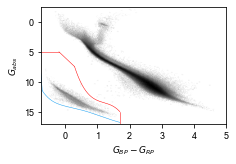

In [9]:
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=True)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)


pac.plot_bkg_cmd(colours=['bp','rp'])
pac.plot_nicola_cuts()
pac.plot_nicola_flag()
plt.ylabel(r'$G_{{abs}}$')
plt.xlabel(r'$G_{BP} - G_{RP}$')
plt.ylim(17,-2.5)
plt.xlim(-0.75,5)
plt.subplots_adjust(wspace = 0, hspace = 0, top = 0.90, bottom = 0.10, left = 0.12, right = 0.90)
#plt.legend()
print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig("HR_diagram_"+time_string+'.pdf')#plt.grid(True)

plt.show()


#plt.show()

Ay oh! It worked! Now onto the division by group. I need to check what the column name is... And I'll probably need to reimpose it onto the CSV again...

In [10]:
#sub_vals= np.where(target_table['good_obs']== 1)
#sub_vals=np.where(target_table['gf19']=='TRUE')

In [11]:
#sub_table= target_table[sub_vals]
#I no longer want some spinoff table that I made for no apparent reason
sub_table=target_table

In [12]:
dz= np.where(sub_table['sp_type']=='DZ')

In [13]:
print(sub_table[dz])
print('rows=',len(sub_table[dz]))
num_dz=len(sub_table[dz])

     name               designation           ... sed_sp_type    g_abs   
------------- ------------------------------- ... ----------- -----------
WD J1644-0449 b'Gaia DR2 4353607450860305024' ...           1 15.97793417
 WD J2356-209 b'Gaia DR2 2341622358827194880' ...           1 15.92918491
rows= 2


In [14]:
wddm= np.where(sub_table['sp_type']=='WDdM')

In [15]:
print(sub_table[wddm])
print('rows=',len(sub_table[wddm]))
num_wddm=len(sub_table[wddm])

       name                 designation           ... sed_sp_type    g_abs   
----------------- ------------------------------- ... ----------- -----------
MORDOR J0110-5600 b'Gaia DR2 4913565903725184640' ...          -- 14.64666791
MORDOR J0126-4707 b'Gaia DR2 4930805868092016256' ...          -- 14.39357931
  SDSS J0132+1823 b'Gaia DR2 2593774421282488832' ...           3 14.64289736
MORDOR J0349+1241   b'Gaia DR2 37101100029189376' ...           3 15.17601185
MORDOR J0419-0745 b'Gaia DR2 3192967924382400256' ...           3 15.43730922
MORDOR J0424-2001 b'Gaia DR2 5091988397208440448' ...           3 14.36747396
 WISEA J0615-1247 b'Gaia DR2 3000597125173673088' ...           3 15.23443206
MORDOR J0706-4246 b'Gaia DR2 5559594371631444736' ...          -- 15.11902738
MORDOR J0746-7004 b'Gaia DR2 5270620145795842432' ...          -- 15.02023542
  SDSS J0824+2705  b'Gaia DR2 683016588814929280' ...           3 14.14323542
  SDSS J1129+2357 b'Gaia DR2 3992722441561708288' ...           

In [16]:
dc= np.where(sub_table['sp_type']=='DC')

In [17]:
print(sub_table[dc])
print('rows=',len(sub_table[dc]))
num_dc=len(sub_table[dc])

       name                 designation           ... sed_sp_type    g_abs   
----------------- ------------------------------- ... ----------- -----------
MORDOR J0008-2404 b'Gaia DR2 2336521827465439616' ...           4 15.83131084
  SDSS J0049+2244 b'Gaia DR2 2802321579156605568' ...           4 15.07368014
MORDOR J0110-5926 b'Gaia DR2 4909222871450620416' ...          -- 15.45486534
MORDOR J0135-6306 b'Gaia DR2 4712157368044092928' ...          -- 14.54516856
  LSPM J0211+0835 b'Gaia DR2 2521858084423378176' ...           4 14.54609154
MORDOR J0225-3312 b'Gaia DR2 4967454759604815360' ...          -- 15.14265539
MORDOR J0248-1556 b'Gaia DR2 5156753037993200512' ...           4 14.82387911
  LSPM J0253+2135  b'Gaia DR2 109336535778050944' ...           4 14.48395214
MORDOR J0325+1236   b'Gaia DR2 17497872857713920' ...           4 15.78141271
MORDOR J0341-1029 b'Gaia DR2 5115934390366550656' ...           4 15.18827731
              ...                             ... ...         ..

In [18]:
dqpec=np.where(sub_table['sp_type']=='DQpec')

In [19]:
print(sub_table[dqpec])
print('rows=',len(sub_table[dqpec]))
num_dqpec=len(sub_table[dqpec])

       name                 designation           ... sed_sp_type    g_abs   
----------------- ------------------------------- ... ----------- -----------
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ...           4 15.68093688
MORDOR J0334-6348 b'Gaia DR2 4673772519470806144' ...          -- 15.13436193
MORDOR J2053+1302 b'Gaia DR2 1761085712628042112' ...           2 15.38574317
MORDOR J2236-3635 b'Gaia DR2 6596688068617463808' ...          -- 15.00936177
rows= 4


In [20]:
unknown=np.where(sub_table['sp_type']=='??')
print(sub_table[unknown])
print('rows=',len(sub_table[unknown]))
num_unknown=len(sub_table[unknown])

       name                 designation           ... sed_sp_type    g_abs   
----------------- ------------------------------- ... ----------- -----------
MORDOR J0253-3334 b'Gaia DR2 5051990775531173120' ...          --  14.3815778
MORDOR J0329-4306 b'Gaia DR2 4849260661232437504' ...          -- 15.40978496
MORDOR J0548-5340 b'Gaia DR2 4768125052520236032' ...          -- 14.99238538
MORDOR J0609-1736 b'Gaia DR2 2943040474599473024' ...           5 14.86711585
MORDOR J0628-3602 b'Gaia DR2 5581206101598276992' ...          -- 15.64044106
MORDOR J1301-2722 b'Gaia DR2 6187146135032473344' ...           4  15.4969728
MORDOR J2114-1218 b'Gaia DR2 6891929583743053696' ...           2 15.57887228
MORDOR J2126-7502 b'Gaia DR2 6368907055055475968' ...          -- 14.39426157
rows= 8


In [21]:
len(sub_table)

120

In [22]:
sub_table.pprint()

       name                 designation           ... sed_sp_type    g_abs   
----------------- ------------------------------- ... ----------- -----------
MORDOR J0008-2404 b'Gaia DR2 2336521827465439616' ...           4 15.83131084
  SDSS J0049+2244 b'Gaia DR2 2802321579156605568' ...           4 15.07368014
MORDOR J0110-5926 b'Gaia DR2 4909222871450620416' ...          -- 15.45486534
MORDOR J0110-5600 b'Gaia DR2 4913565903725184640' ...          -- 14.64666791
MORDOR J0126-4707 b'Gaia DR2 4930805868092016256' ...          -- 14.39357931
  SDSS J0132+1823 b'Gaia DR2 2593774421282488832' ...           3 14.64289736
MORDOR J0135-6306 b'Gaia DR2 4712157368044092928' ...          -- 14.54516856
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ...           4 15.68093688
  LSPM J0211+0835 b'Gaia DR2 2521858084423378176' ...           4 14.54609154
MORDOR J0225-3312 b'Gaia DR2 4967454759604815360' ...          -- 15.14265539
              ...                             ... ...         ..

In [23]:
#for row in sub_table:
#    print(row['sp_type'])

In [24]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
#colours= ['g', 'rp']
colours= ['bp', 'rp']

<Figure size 720x360 with 0 Axes>

(22288,)


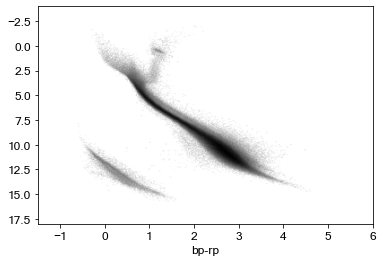

In [25]:
pac.plot_bkg_cmd(colours=colours)

1.4843978934820363 15.836777863860455
MORDOR J0008-2404
1.4597580104437569 15.080193003839463
SDSS J0049+2244
1.2465963645092906 15.461686437323877
MORDOR J0110-5926
1.0707204641623953 14.554334895776861
MORDOR J0135-6306
1.4128170464424628 14.551658367489678
LSPM J0211+0835
1.177134193202935 15.150044426429602
MORDOR J0225-3312
1.3439732425382367 14.831057715255957
MORDOR J0248-1556
1.3315728599839751 14.490034414042423
LSPM J0253+2135
1.2947473581931668 15.785994329613844
MORDOR J0325+1236
1.0681499281986184 15.194061067899991
MORDOR J0341-1029
1.1913713290272128 14.642467851206288
MORDOR J0400-2041
1.5466039445407702 16.089042752909556
MORDOR J0431+1502
1.4886765497692451 15.293989851196297
MORDOR J0433-4252
1.5482265243808726 15.018857478626131
PSR J0437-47
1.430410796029669 15.264085057393519
MORDOR J0438-3913
1.3734821893398177 16.239019689502705
MORDOR J0445-6245
1.405062857645774 14.593901285472498
SDSS J0447+2430
1.3406602516848665 14.239825921729057
SDSS J0521+2547
1.22368050

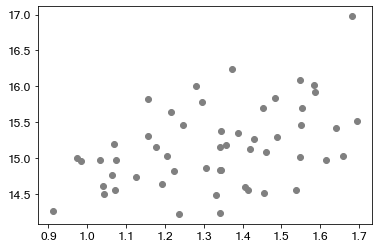

In [26]:
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey')

1.7183519570145123 15.983156795809741
WD J1644-0449
1.8052624885258055 15.933263242899619
WD J2356-209


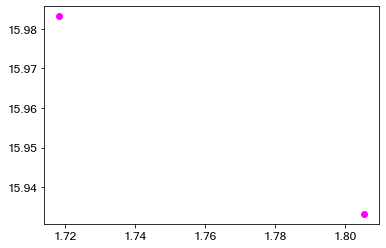

In [27]:
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta')

1.3187456557010577 14.654582033860546
MORDOR J0110-5600
2.577529078407224 14.398589010194087
MORDOR J0126-4707
1.7205957965497376 14.650036588087136
SDSS J0132+1823
2.1110853183300904 15.181730070341192
MORDOR J0349+1241
2.14790346979046 15.440956212249764
MORDOR J0419-0745
1.2688612908520476 14.37470449168617
MORDOR J0424-2001
2.4283307791710946 15.236859277762573
WISEA J0615-1247
1.3962000984025664 15.125934745507424
MORDOR J0706-4246
1.4068547265365616 15.028304719495896
MORDOR J0746-7004
1.3295133654419828 14.151799142972585
SDSS J0824+2705
2.021182217491493 14.540148986916844
SDSS J1129+2357
2.135669977089748 14.414029592948028
SDSS J1159+1039
1.7373592584277233 14.13991107297404
MORDOR J1357-1901
1.387534696666389 14.456962426004086
SDSS J1555+1330
2.588154210455336 14.366929235821104
WISEA J1615-0850
2.3205980303649127 14.629662112975334
MORDOR J1700+2713


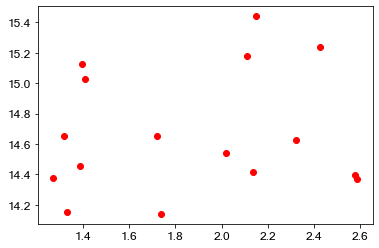

In [28]:
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r')

1.5229095460173383 15.685338645993514
LEHPM 1774
1.8254021695109621 15.140734424709395
MORDOR J0334-6348
1.9622870890245956 15.39159628926175
MORDOR J2053+1302
1.2901202607261801 15.016479459303516
MORDOR J2236-3635


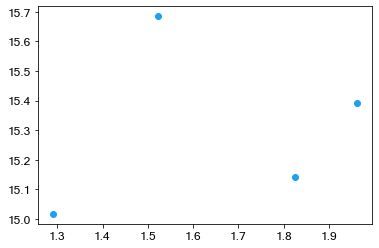

In [29]:
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2')

Text(0, 0.5, '$M_{G}$')

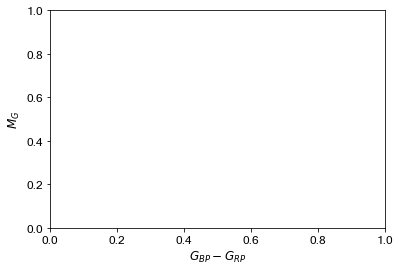

In [30]:
#plt.xlabel(r'$G-G_{RP}$')
plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')
#plt.xlim(-0.5, 2)

In [31]:
plt.show()

## BP-RP H-R diagram

(22288,)
1.4843978934820363 15.836777863860455
MORDOR J0008-2404
1.4597580104437569 15.080193003839463
SDSS J0049+2244
1.2465963645092906 15.461686437323877
MORDOR J0110-5926
1.0707204641623953 14.554334895776861
MORDOR J0135-6306
1.4128170464424628 14.551658367489678
LSPM J0211+0835
1.177134193202935 15.150044426429602
MORDOR J0225-3312
1.3439732425382367 14.831057715255957
MORDOR J0248-1556
1.3315728599839751 14.490034414042423
LSPM J0253+2135
1.2947473581931668 15.785994329613844
MORDOR J0325+1236
1.0681499281986184 15.194061067899991
MORDOR J0341-1029
1.1913713290272128 14.642467851206288
MORDOR J0400-2041
1.5466039445407702 16.089042752909556
MORDOR J0431+1502
1.4886765497692451 15.293989851196297
MORDOR J0433-4252
1.5482265243808726 15.018857478626131
PSR J0437-47
1.430410796029669 15.264085057393519
MORDOR J0438-3913
1.3734821893398177 16.239019689502705
MORDOR J0445-6245
1.405062857645774 14.593901285472498
SDSS J0447+2430
1.3406602516848665 14.239825921729057
SDSS J0521+2547
1

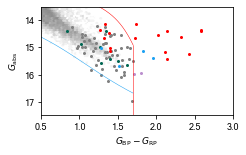

In [32]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)

#colours= ['g', 'rp']
colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)

#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2',markersize=cp.plot_marker_size)

pac.plot_target_table(sub_table[dc], colours=colours, list_color=cp.sp_type_colors['DC'],label='DC',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[unknown], colours=colours, list_color=cp.sp_type_colors['??'],label='Unknown',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dz], colours=colours, list_color= cp.sp_type_colors['DZ'],label='DZ',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[wddm],colours=colours, list_color=cp.sp_type_colors['WDdM'],label='WD+dM',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  cp.sp_type_colors['DQpec'],label='DQpec',markersize=cp.hrd_plot_marker_size)

pac.plot_nicola_cuts()
pac.plot_nicola_flag()


#plt.xlabel(r'$G-G_{RP}$')

plt.xlabel(r'$G_{\rm{BP}}-G_{\rm{RP}}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{\rm{abs}}$')

#plt.legend()

#plt.xlim(0.5, 1.5)
#plt.ylim(17.5,12.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.75,5)
plt.ylim(17.5,13.5)
plt.xlim(0.5,3)

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
plt.savefig("HR_diagram_GentileFusillo2019_"+time_string+'.pdf')#plt.grid(True)

plt.show()




In [33]:
plt.show()

In [34]:
parallax = sub_table['parallax']+pac.parallax_correction
parallax = parallax*1e-3
distance = 1./parallax
absmags=[]
#for row in sub_table:
    #this_abs, throw, garbage= pac.get_pass_abs_mag(target_table, plot_all=False, passband_string='g')
    #absmags.append(this_abs)

In [35]:
print(len(sub_table[dz]))
print(len(sub_table[dqpec]))
print(len(sub_table[dc]))
print(len(sub_table[wddm]))
print(len(sub_table))

2
4
53
16
120


## G-RP H-R diagram

(22981,)
1.0138221850612084 15.836777863860455
MORDOR J0008-2404
0.9510014761821459 15.080193003839463
SDSS J0049+2244
1.0376613331233422 15.461686437323877
MORDOR J0110-5926
0.9681389980781638 14.654582033860546
MORDOR J0110-5600
1.3014429277707364 14.398589010194087
MORDOR J0126-4707
1.041212594645085 14.650036588087136
SDSS J0132+1823
0.9801911167882231 14.554334895776861
MORDOR J0135-6306
0.9801358082016591 15.685338645993514
LEHPM 1774
0.8889288937032376 14.551658367489678
LSPM J0211+0835
1.047885068697802 15.150044426429602
MORDOR J0225-3312
0.9978632874157114 15.363195685633372
MORDOR J0244+8145
0.9243710506431135 14.831057715255957
MORDOR J0248-1556
1.1118883346637602 14.390042033356185
MORDOR J0253-3334
0.8677604345417507 14.490034414042423
LSPM J0253+2135
0.8967966698710939 14.59962024427193
MORDOR J0319-7359
1.0449423630117138 15.785994329613844
MORDOR J0325+1236
1.046947188098308 15.41650993420406
MORDOR J0329-4306
0.9894360158508313 15.140734424709395
MORDOR J0334-6348
1.0

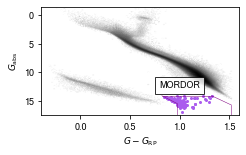

In [36]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)
colours= ['g', 'rp']
#colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)
pac.plot_target_table(target_table, colours=colours, list_color='#AB5DEE',markersize=cp.hrd_plot_marker_size,annotate=False)
#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey')
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r')
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2')
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta')
#pac.plot_nicola_cuts()
pac.plot_ben_cuts()

plt.xlabel(r'$G-G_{\rm{RP}}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{\rm{abs}}$')

plt.text(1.0,13.0,'MORDOR',verticalalignment='bottom',horizontalalignment='center',bbox=dict(facecolor='white',alpha=0.8))

#plt.legend()

#plt.xlim(0.5, 1.5)
#plt.ylim(17.5,12.5)

plt.ylim(17.5,-1.5)
#plt.xlim(-0.4,2.0)
plt.xlim(-0.4,1.6)


print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
plt.savefig("HR_diagram_GRP_"+time_string+'.pdf')#plt.grid(True)

plt.show()





## Zoomed in G-RP H-R diagram

(22981,)
1.0138221850612084 15.836777863860455
MORDOR J0008-2404
0.9510014761821459 15.080193003839463
SDSS J0049+2244
1.0376613331233422 15.461686437323877
MORDOR J0110-5926
0.9801911167882231 14.554334895776861
MORDOR J0135-6306
0.8889288937032376 14.551658367489678
LSPM J0211+0835
1.047885068697802 15.150044426429602
MORDOR J0225-3312
0.9243710506431135 14.831057715255957
MORDOR J0248-1556
0.8677604345417507 14.490034414042423
LSPM J0253+2135
1.0449423630117138 15.785994329613844
MORDOR J0325+1236
1.0123130389463633 15.194061067899991
MORDOR J0341-1029
0.9560551848564245 14.642467851206288
MORDOR J0400-2041
1.1284758163161293 16.089042752909556
MORDOR J0431+1502
1.0385412419562279 15.293989851196297
MORDOR J0433-4252
0.9490068416819497 15.018857478626131
PSR J0437-47
0.9776790866116443 15.264085057393519
MORDOR J0438-3913
1.1343220212017613 16.239019689502705
MORDOR J0445-6245
0.940905485228555 14.593901285472498
SDSS J0447+2430
0.8600899100255432 14.239825921729057
SDSS J0521+2547


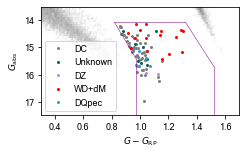

In [37]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,6), constrained_layout=False)
#plt.figure(figsize=(6.5,6/9.5*6.5), constrained_layout=True)
spt.start_mnras_fig(width_cols=1)

colours= ['g', 'rp']
#colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)
#pac.plot_target_table(target_table, colours=colours, list_color='#AB5DEE',markersize=6,annotate=False)
#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey',label='DC-'+str(num_dc))
#pac.plot_target_table(sub_table[unknown], colours=colours, list_color='#006652',label='Unknown-'+str(num_unknown))
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta',label='DZ-'+str(num_dz))
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r',label='WD+dM-'+str(num_wddm))
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))
pac.plot_target_table(sub_table[dc], colours=colours, list_color=cp.sp_type_colors['DC'],label='DC',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[unknown], colours=colours, list_color=cp.sp_type_colors['??'],label='Unknown',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dz], colours=colours, list_color= cp.sp_type_colors['DZ'],label='DZ',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[wddm],colours=colours, list_color=cp.sp_type_colors['WDdM'],label='WD+dM',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  cp.sp_type_colors['DQpec'],label='DQpec',markersize=cp.hrd_plot_marker_size)

#pac.plot_nicola_cuts()
pac.plot_ben_cuts(show_name=False)

plt.xlabel(r'$G-G_{\rm{RP}}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{\rm{abs}}$')


#plt.legend()

#plt.xlim(0.4, 1.8)
plt.xlim(0.3, 1.7)

plt.ylim(17.5,13.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.4,2.0)
plt.legend(loc='lower left')

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
plt.savefig("HR_diagram_GRP_zoomed"+time_string+'.pdf')#plt.grid(True)

plt.show()






(22981,)
1.0138221850612084 15.836777863860455
MORDOR J0008-2404
0.9510014761821459 15.080193003839463
SDSS J0049+2244
1.0376613331233422 15.461686437323877
MORDOR J0110-5926
0.9801911167882231 14.554334895776861
MORDOR J0135-6306
0.8889288937032376 14.551658367489678
LSPM J0211+0835
1.047885068697802 15.150044426429602
MORDOR J0225-3312
0.9243710506431135 14.831057715255957
MORDOR J0248-1556
0.8677604345417507 14.490034414042423
LSPM J0253+2135
1.0449423630117138 15.785994329613844
MORDOR J0325+1236
1.0123130389463633 15.194061067899991
MORDOR J0341-1029
0.9560551848564245 14.642467851206288
MORDOR J0400-2041
1.1284758163161293 16.089042752909556
MORDOR J0431+1502
1.0385412419562279 15.293989851196297
MORDOR J0433-4252
0.9490068416819497 15.018857478626131
PSR J0437-47
0.9776790866116443 15.264085057393519
MORDOR J0438-3913
1.1343220212017613 16.239019689502705
MORDOR J0445-6245
0.940905485228555 14.593901285472498
SDSS J0447+2430
0.8600899100255432 14.239825921729057
SDSS J0521+2547


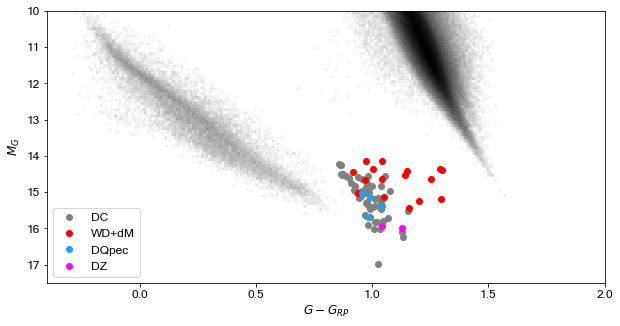

In [38]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
#colours= ['bp', 'rp']
colours= ['g', 'rp']
pac.plot_bkg_cmd(colours=colours)
#pac.plot_nicola_cuts()
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey', label='DC')
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r', label='WD+dM')
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2', label='DQpec')
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta', label='DZ')
plt.xlabel(r'$G-G_{RP}$')
#plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')

#plt.xlim(-0.5, 1.5)
#plt.ylim(17.5,7.5)

plt.xlim(-0.4, 2.0)
#plt.xlim(0,4)
plt.ylim(17.5,10)



plt.legend()
plt.legend(loc='lower left')



In [39]:
plt.show()

(22288,)
1.4843978934820363 15.836777863860455
MORDOR J0008-2404
1.4597580104437569 15.080193003839463
SDSS J0049+2244
1.2465963645092906 15.461686437323877
MORDOR J0110-5926
1.0707204641623953 14.554334895776861
MORDOR J0135-6306
1.4128170464424628 14.551658367489678
LSPM J0211+0835
1.177134193202935 15.150044426429602
MORDOR J0225-3312
1.3439732425382367 14.831057715255957
MORDOR J0248-1556
1.3315728599839751 14.490034414042423
LSPM J0253+2135
1.2947473581931668 15.785994329613844
MORDOR J0325+1236
1.0681499281986184 15.194061067899991
MORDOR J0341-1029
1.1913713290272128 14.642467851206288
MORDOR J0400-2041
1.5466039445407702 16.089042752909556
MORDOR J0431+1502
1.4886765497692451 15.293989851196297
MORDOR J0433-4252
1.5482265243808726 15.018857478626131
PSR J0437-47
1.430410796029669 15.264085057393519
MORDOR J0438-3913
1.3734821893398177 16.239019689502705
MORDOR J0445-6245
1.405062857645774 14.593901285472498
SDSS J0447+2430
1.3406602516848665 14.239825921729057
SDSS J0521+2547
1

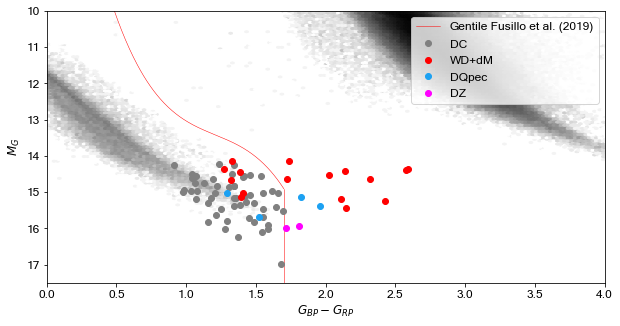

In [40]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
colours= ['bp', 'rp']
#colours= ['g', 'rp']
pac.plot_bkg_cmd(colours=colours)
pac.plot_nicola_cuts()
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey', label='DC')
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r', label='WD+dM')
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2', label='DQpec')
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta', label='DZ')
#plt.xlabel(r'$G-G_{RP}$')
plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')

#plt.xlim(-0.5, 1.5)
#plt.ylim(17.5,7.5)

#plt.xlim(-0.25, 1.5)
plt.xlim(0,4)
plt.ylim(17.5,10)



plt.legend()
#plt.legend(loc='lower left')
plt.legend(loc='upper right')






In [41]:
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92

2021-06-16 updated version counts:

2

4

26

12

120

## PanSTARRS-2 Color-Color diagrams (2022-05-02)

import the panstarrs plotting code I wrote externally earlier

In [42]:
plt.show()

In [43]:
#plt.rc('font',size=12)
plt.rc('font',family='Microsoft Sans Serif',size=18)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
plt.figure(figsize=(9.5,6), constrained_layout=False)

#c1c2='g-r'
#c3c4='r-i'

c1c2='g-y'
c3c4='r-i'



pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table,color=  'k',label='Obj. w/out spectrum')
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dc],color='grey',label='DC-'+str(num_dc))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[unknown], color='#006652',label='??-'+str(num_unknown))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dz], color= 'magenta',label='DZ-'+str(num_dz))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[wddm],color='r',label='WD+dM-'+str(num_wddm))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dqpec],color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))





#pac.plot_nicola_cuts()
#pac.plot_ben_cuts()

#plt.xlabel(r'$G-G_{RP}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
#plt.legend()

#plt.xlim(0.4, 1.8)
#plt.ylim(17.5,13.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.4,2.0)
plt.legend(loc='best',fontsize=16)

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig(c3c4+'_vs_'+c1c2+'_'+time_string+'.pdf')#plt.grid(True)

plt.show()



KeyError: 'ps1_g_mean_mag'

<Figure size 684x432 with 0 Axes>

#plt.rc('font',size=12)
plt.rc('font',family='Microsoft Sans Serif',size=18)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
plt.figure(figsize=(9.5,6), constrained_layout=False)

c1c2='g-r'
c3c4='r-i'

color_list=['g','r','i','z','y']

for color1 in color_list:
    for color2 in color_list:
        c1c2=color1+'-'+color2
        print(c1c2)
        if color1 != color2:
            for color3 in color_list:
                for color4 in color_list:
                    c3c4=color3+'-'+color4
                    print(c3c4)
                    if ((color3 != color4) and (c1c2 != c3c4)):
                        #do the plotting
                        print('should be plotting')

                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dc],color='grey',label='DC-'+str(num_dc))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[unknown], color='#006652',label='??-'+str(num_unknown))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dz], color= 'magenta',label='DZ-'+str(num_dz))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[wddm],color='r',label='WD+dM-'+str(num_wddm))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dqpec],color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))




                        #pac.plot_nicola_cuts()
                        #pac.plot_ben_cuts()

                        #plt.xlabel(r'$G-G_{RP}$')

                        #plt.xlabel(r'$G_{BP}-G_{RP}$')
                        #plt.ylabel(r'$M_{G}$')
                        #plt.legend()

                        #plt.xlim(0.4, 1.8)
                        #plt.ylim(17.5,13.5)

                        #plt.ylim(17,-1.5)
                        #plt.xlim(-0.4,2.0)
                        plt.legend(loc='best',fontsize=16)

                        print(os.getcwd())
                        os.chdir(figure_output_dir)
                        print(os.getcwd())
                        start = time.time()
                        print(start)
                        time_string=str(start).split('.')[0]
                        plt.savefig(c3c4+'_vs_'+c1c2+'_'+time_string+'.pdf')#plt.grid(True)

                        plt.show()


                    else:
                        pass
        else:
            pass

In [ ]:
(2+50+16+5)/83.